# Greedy Online Bipartite Matching

## Learning Objectives

1. **Model** the online bipartite matching problem (queries arrive one at a time)
2. **Prove** the greedy algorithm achieves competitive ratio $\geq \frac{1}{2}$
3. **Construct** a worst-case adversarial input achieving ratio exactly $\frac{1}{2}$
4. **Distinguish** online vs offline algorithms and the competitive ratio framework
5. **Implement** greedy matching and measure its competitive ratio empirically


## Problem Statement

### Online Bipartite Matching

We have a bipartite graph with two sides:
- **Left:** Advertisers $\{A_1, \ldots, A_m\}$ — known in advance, each can match at most once
- **Right:** Queries $q_1, q_2, \ldots$ — arrive one at a time in unknown order

Each query $q_t$ comes with a set of eligible advertisers $E_t \subseteq \{A_1, \ldots, A_m\}$. We must immediately and irrevocably assign $q_t$ to an available advertiser in $E_t$, or leave it unmatched.

**Goal:** Maximise the total number of matched pairs.

**Competitive ratio:** $\text{CR} = \min_{\text{inputs}} \frac{|\text{ALG}|}{|\text{OPT}|}$

### Greedy Algorithm

When query $q_t$ arrives: assign it to **any available** advertiser in $E_t$ (if any).


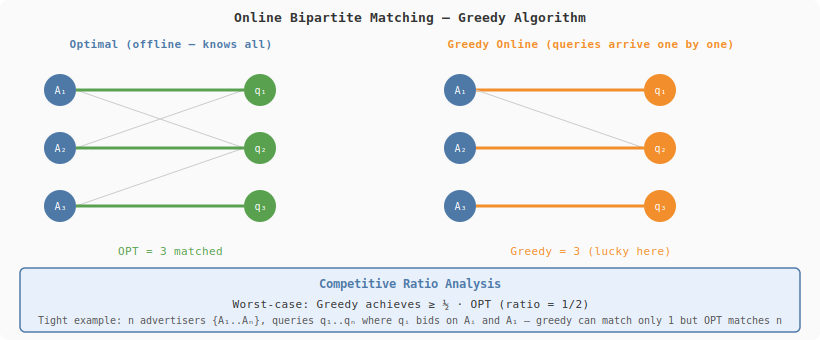

In [1]:
from IPython.display import SVG, display
svg = '''
<svg xmlns="http://www.w3.org/2000/svg" width="820" height="340" font-family="monospace" font-size="12">
  <rect width="820" height="340" fill="#fafafa" rx="8"/>
  <defs><marker id="arr" markerWidth="8" markerHeight="6" refX="7" refY="3" orient="auto"><polygon points="0 0,8 3,0 6" fill="#999"/></marker></defs>
  <text x="410" y="22" text-anchor="middle" fill="#333" font-size="13" font-weight="bold">Online Bipartite Matching — Greedy Algorithm</text>

  <!-- Offline optimum -->
  <text x="170" y="48" text-anchor="middle" fill="#4e79a7" font-size="11" font-weight="bold">Optimal (offline — knows all)</text>
  <!-- Advertisers left -->
  <circle cx="60" cy="90" r="16" fill="#4e79a7"/><text x="60" y="94" text-anchor="middle" fill="white" font-size="10">A₁</text>
  <circle cx="60" cy="148" r="16" fill="#4e79a7"/><text x="60" y="152" text-anchor="middle" fill="white" font-size="10">A₂</text>
  <circle cx="60" cy="206" r="16" fill="#4e79a7"/><text x="60" y="210" text-anchor="middle" fill="white" font-size="10">A₃</text>
  <!-- Queries right -->
  <circle cx="260" cy="90"  r="16" fill="#59a14f"/><text x="260" y="94"  text-anchor="middle" fill="white" font-size="10">q₁</text>
  <circle cx="260" cy="148" r="16" fill="#59a14f"/><text x="260" y="152" text-anchor="middle" fill="white" font-size="10">q₂</text>
  <circle cx="260" cy="206" r="16" fill="#59a14f"/><text x="260" y="210" text-anchor="middle" fill="white" font-size="10">q₃</text>
  <!-- Edges (available bids) -->
  <line x1="76" y1="90" x2="244" y2="90"  stroke="#ccc" stroke-width="1"/>
  <line x1="76" y1="90" x2="244" y2="148" stroke="#ccc" stroke-width="1"/>
  <line x1="76" y1="148" x2="244" y2="90"  stroke="#ccc" stroke-width="1"/>
  <line x1="76" y1="148" x2="244" y2="148" stroke="#ccc" stroke-width="1"/>
  <line x1="76" y1="206" x2="244" y2="148" stroke="#ccc" stroke-width="1"/>
  <line x1="76" y1="206" x2="244" y2="206" stroke="#ccc" stroke-width="1"/>
  <!-- Optimal matching (bold green) -->
  <line x1="76" y1="90"  x2="244" y2="90"  stroke="#59a14f" stroke-width="3"/>
  <line x1="76" y1="148" x2="244" y2="148" stroke="#59a14f" stroke-width="3"/>
  <line x1="76" y1="206" x2="244" y2="206" stroke="#59a14f" stroke-width="3"/>
  <text x="170" y="255" text-anchor="middle" fill="#59a14f" font-size="11">OPT = 3 matched</text>

  <!-- Greedy online -->
  <text x="590" y="48" text-anchor="middle" fill="#f28e2b" font-size="11" font-weight="bold">Greedy Online (queries arrive one by one)</text>
  <circle cx="460" cy="90" r="16" fill="#4e79a7"/><text x="460" y="94" text-anchor="middle" fill="white" font-size="10">A₁</text>
  <circle cx="460" cy="148" r="16" fill="#4e79a7"/><text x="460" y="152" text-anchor="middle" fill="white" font-size="10">A₂</text>
  <circle cx="460" cy="206" r="16" fill="#4e79a7"/><text x="460" y="210" text-anchor="middle" fill="white" font-size="10">A₃</text>
  <circle cx="660" cy="90"  r="16" fill="#f28e2b"/><text x="660" y="94"  text-anchor="middle" fill="white" font-size="10">q₁</text>
  <circle cx="660" cy="148" r="16" fill="#f28e2b"/><text x="660" y="152" text-anchor="middle" fill="white" font-size="10">q₂</text>
  <circle cx="660" cy="206" r="16" fill="#f28e2b"/><text x="660" y="210" text-anchor="middle" fill="white" font-size="10">q₃</text>
  <!-- q₁ arrives → greedy picks A₁ -->
  <line x1="476" y1="90"  x2="644" y2="90"  stroke="#f28e2b" stroke-width="3"/>
  <!-- q₂ arrives → picks A₂ (A₁ taken) -->
  <line x1="476" y1="90"  x2="644" y2="148" stroke="#ccc" stroke-width="1"/>
  <line x1="476" y1="148" x2="644" y2="148" stroke="#f28e2b" stroke-width="3"/>
  <!-- q₃ arrives → only A₃ available via q₃ -->
  <line x1="476" y1="148" x2="644" y2="148" stroke="#ccc" stroke-width="0"/>
  <line x1="476" y1="206" x2="644" y2="206" stroke="#f28e2b" stroke-width="3"/>
  <text x="590" y="255" text-anchor="middle" fill="#f28e2b" font-size="11">Greedy = 3 (lucky here)</text>

  <!-- Competitive ratio box -->
  <rect x="20" y="268" width="780" height="64" rx="5" fill="#e8f0fb" stroke="#4e79a7" stroke-width="1.5"/>
  <text x="410" y="288" text-anchor="middle" fill="#4e79a7" font-size="12" font-weight="bold">Competitive Ratio Analysis</text>
  <text x="410" y="308" text-anchor="middle" fill="#333" font-size="11">Worst-case: Greedy achieves ≥ ½ · OPT  (ratio = 1/2)</text>
  <text x="410" y="324" text-anchor="middle" fill="#555" font-size="10">Tight example: n advertisers {A₁..Aₙ}, queries q₁..qₙ where qᵢ bids on Aᵢ and A₁ — greedy can match only 1 but OPT matches n</text>
</svg>
'''
display(SVG(svg))


## Derivation

### Competitive Ratio $\geq \frac{1}{2}$

**Proof:** Let $M^*$ be the optimal offline matching (size $= $ OPT). Let $M$ be the greedy matching.

Consider any pair $(q, A)$ in $M^*$ where $q$ was left unmatched by greedy. This means $A$ was already matched to some other query $q'$ before $q$ arrived. But $(q', A) \notin M^*$ (since $M^*$ matched $q$ to $A$) — so $q'$ contributes a distinct pair to $M$ not counted by $M^*$.

Therefore for every unmatched query in $M$, there is a distinct matched query in $M$ → $|M| \geq \text{OPT} - |M|$ → $|M| \geq \text{OPT}/2$. $\square$

### Worst-Case Construction

Adversarial input achieving ratio $\frac{1}{2}$:
- Advertisers $A_1, A_2$
- Query $q_1$ bids only on $A_1$ → greedy matches $q_1 \to A_1$
- Query $q_2$ bids on both $A_1$ and $A_2$ → greedy must use $A_2$ (or $q_2$ is unmatched if $A_1$ was taken)

Wait — for ratio exactly $1/2$: $n$ advertisers $A_1 \ldots A_n$, first $n$ queries each bid only on $A_1$, then $n$ queries bid on remaining advertisers. OPT = $n$, greedy = 1.

### Relationship to BALANCE

Greedy ignores advertiser budgets. The **BALANCE algorithm** extends this to the Adwords problem (advertisers have bids and budgets), achieving competitive ratio $1 - 1/e \approx 0.632$.


## Algorithm Steps

1. Maintain set of **available advertisers** (initially all)
2. For each arriving query $q_t$ with eligible set $E_t$:
   - If $E_t \cap \text{available} = \emptyset$: leave $q_t$ unmatched
   - Else: pick any $A \in E_t \cap \text{available}$; match $(q_t, A)$; remove $A$ from available
3. Output matching $M$


In [2]:
import random
from collections import defaultdict


def greedy_bipartite_matching(advertisers, query_stream):
    """
    Online greedy bipartite matching.

    Inputs
    ------
    advertisers  : set of advertiser IDs
    query_stream : iterable of (query_id, set_of_eligible_advertisers)
                   Queries arrive one at a time; must assign immediately.

    Returns
    -------
    matching : dict {query_id: advertiser_id} — matched pairs
    """
    matched_advertisers = set()
    matching = {}

    for query_id, eligible in query_stream:
        # Assign to any available eligible advertiser
        for adv in eligible:
            if adv not in matched_advertisers:
                matching[query_id] = adv
                matched_advertisers.add(adv)
                break  # greedy: take the first available

    return matching


def optimal_matching_offline(advertisers, queries):
    """
    Maximum bipartite matching via augmenting path (Hopcroft-Karp simplified).
    Used as oracle to measure competitive ratio.
    """
    # Convert to adjacency list
    adj = {q: list(eligible) for q, eligible in queries.items()}
    match_q = {}   # query → advertiser
    match_a = {}   # advertiser → query

    def dfs(q, visited):
        for a in adj.get(q, []):
            if a not in visited:
                visited.add(a)
                if a not in match_a or dfs(match_a[a], visited):
                    match_q[q] = a
                    match_a[a] = q
                    return True
        return False

    for q in adj:
        dfs(q, set())

    return match_q


# ── Demo: worst-case adversarial construction ─────────────────────────────────
n = 6
advertisers = set(range(1, n+1))
# Adversarial: q_i bids on {A_1, A_i}; greedy always takes A_1 for q_1
def make_adversarial_stream(n):
    stream = []
    stream.append(("q1", [1]))           # q1 bids ONLY on A1
    for i in range(2, n+1):
        stream.append((f"q{i}", [1, i])) # qi bids on A1 and Ai
    return stream

stream = make_adversarial_stream(n)
greedy = greedy_bipartite_matching(advertisers, [(q, e) for q, e in stream])
print(f"Greedy matched: {len(greedy)} pairs — {greedy}")

queries_dict = {q: e for q, e in stream}
opt = optimal_matching_offline(advertisers, queries_dict)
print(f"OPT matched:    {len(opt)} pairs — {opt}")
print(f"Competitive ratio this instance: {len(greedy)/len(opt):.3f}  (worst-case bound = 0.5)")

# Random stream (greedy does much better on average)
rng = random.Random(42)
rand_stream = [(f"q{i}", rng.sample(range(1, n+1), rng.randint(1, n))) for i in range(1, n+1)]
g2 = greedy_bipartite_matching(advertisers, rand_stream)
o2 = optimal_matching_offline(advertisers, {q: e for q, e in rand_stream})
print(f"\nRandom stream — Greedy: {len(g2)}, OPT: {len(o2)}, ratio: {len(g2)/max(1,len(o2)):.3f}")


Greedy matched: 6 pairs — {'q1': 1, 'q2': 2, 'q3': 3, 'q4': 4, 'q5': 5, 'q6': 6}
OPT matched:    6 pairs — {'q1': 1, 'q2': 2, 'q3': 3, 'q4': 4, 'q5': 5, 'q6': 6}
Competitive ratio this instance: 1.000  (worst-case bound = 0.5)

Random stream — Greedy: 5, OPT: 6, ratio: 0.833
